In [1]:
from typing import List, TypedDict
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_groq import ChatGroq
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from dotenv import load_dotenv

load_dotenv()

d:\College\Langchain\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [ ]:
# docs = (
#     PyPDFLoader("./documents/book1.pdf").load()
#     + PyPDFLoader("./documents/book2.pdf").load()
#     + PyPDFLoader("./documents/book3.pdf").load()
# )

In [ ]:
# chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)
# for d in chunks:
#     d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [2]:
# vector_store = FAISS.from_documents(chunks, embeddings)
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")
vector_store = FAISS.load_local(
    "faiss_index",
    embeddings,
    allow_dangerous_deserialization=True
)
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})

In [3]:
llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0)

In [4]:
class State(TypedDict):
    question: str
    docs: List[Document]

    strips: List[str]            # output of decomposition (sentence strips)
    kept_strips: List[str]       # after filtering (kept sentences)
    refined_context: str         # recomposed internal knowledge (joined kept_strips)

    answer: str

In [5]:
def retrieve(state: State) -> State:
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [6]:
# -----------------------------
# Sentence-level DECOMPOSER
# -----------------------------
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


# -----------------------------
# FILTER (LLM judge)
# -----------------------------
class KeepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop, method="json_mode")


# -----------------------------
# REFINING (Decompose -> Filter -> Recompose)
# -----------------------------
def refine(state: State) -> State:

    q = state["question"]

    # Combine retrieved docs into one context string
    context = "\n\n".join(d.page_content for d in state["docs"]).strip()

    # 1) DECOMPOSITION: context -> sentence strips
    strips = decompose_to_sentences(context)

    # 2) FILTER: keep only relevant strips
    kept: List[str] = []
    
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    # 3) RECOMPOSE: glue kept strips back together (internal knowledge)
    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }


In [7]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke({"question": state["question"], "refined_context": state['refined_context']})
    return {"answer": out.content}

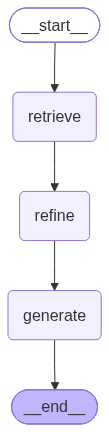

In [8]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("refine", refine)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "refine")
g.add_edge("refine", "generate")
g.add_edge("generate", END)

app = g.compile()

app

In [9]:
res = app.invoke({
    "question": "Explain the bias–variance tradeoff",
    "docs": [],
    "strips": [],
    "kept_strips": [],
    "refined_context": "",
    "answer": ""
})
print(res["answer"])

The bias–variance trade‑off describes how the expected prediction error of a learning model can be split into two competing components:

* **Squared bias** – the error that arises because the **average prediction** of the model (the expectation over all possible training sets) does **not** match the true regression function \(h(x)\).  Mathematically it is  
  \[
  (\text{bias})^{2}= \frac{1}{N}\sum_{n=1}^{N}\bigl\{y(x_{n})-h(x_{n})\bigr\}^{2},
  \]
  where \(y(x_{n})\) is the average prediction at point \(x_{n}\).

* **Variance** – the error that arises because the model’s prediction for a **particular training set** fluctuates around the average prediction.  It is measured by  
  \[
  \text{variance}= \frac{1}{N}\sum_{n=1}^{N}\frac{1}{L}\sum_{\ell=1}^{L}
  \bigl\{y^{(\ell)}(x_{n})-y(x_{n})\bigr\}^{2},
  \]
  where \(y^{(\ell)}(x_{n})\) is the prediction from the \(\ell\)‑th data set and \(y(x_{n})\) is the average over all data sets.

When we take the expectation of the squared error 

In [10]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

with respect to multiple data sets.
We can also examine the bias-variance trade-off quantitatively for this example.
The average prediction is estimated from
y(x)= 1
L
L∑
l=1
y(l)(x) (3.45)
and the integrated squared bias and integrated variance are then given by
(bias)2 = 1
N
N∑
n=1
{y(xn) − h(xn)}2 (3.46)
variance = 1
N
N∑
n=1
1
L
L∑
l=1
{
y(l)(xn) − y(xn)
}2
(3.47)
where the integral over x weighted by the distribution p(x) is approximated by a
ﬁnite sum over data points drawn from that distribution. These quantities, along
with their sum, are plotted as a function of lnλ in Figure 3.6. We see that small
values of λ allow the model to become ﬁnely tuned to the noise on each individual
****************************************************************************************************
3.2. The Bias-Variance Decomposition 149
inside the braces, and then expand, we obtain
{y(x;D) − ED[y(x;D)] +ED[y(x;D)] − h(x)}2
= {y(x;D) − ED[y(x;D)]}2 + {ED[y(x;D)] − h(x)}2
+2{y(x;D) − ED[y(x; D)]}{

In [11]:
print(res['refined_context'])

The average prediction is estimated from y(x)= 1 L L∑ l=1 y(l)(x) (3.45) and the integrated squared bias and integrated variance are then given by (bias)2 = 1 N N∑ n=1 {y(xn) − h(xn)}2 (3.46) variance = 1 N N∑ n=1 1 L L∑ l=1 { y(l)(xn) − y(xn) }2 (3.47) where the integral over x weighted by the distribution p(x) is approximated by a ﬁnite sum over data points drawn from that distribution.
We see that small values of λ allow the model to become ﬁnely tuned to the noise on each individual 3.2.
The Bias-Variance Decomposition 149 inside the braces, and then expand, we obtain {y(x;D) − ED[y(x;D)] +ED[y(x;D)] − h(x)}2 = {y(x;D) − ED[y(x;D)]}2 + {ED[y(x;D)] − h(x)}2 +2{y(x;D) − ED[y(x; D)]}{ED[y(x; D)] − h(x)}.
(3.39) We now take the expectation of this expression with respect to D and note that the ﬁnal term will vanish, giving ED [ {y(x;D) − h(x)}2] = {ED[y(x;D)] − h(x)}2    (bias)2 + ED [ {y(x;D) − ED[y(x;D)]}2]    variance .
(3.40) We see that the expected squared difference betw